# 1 month salt budget test for ACCESS control, shelf only

Trying to see whether salinity change on shelf is primarily from advection vs surface fluxes.

In [1]:
import glob
import dask.distributed as dsk
import matplotlib.pyplot as plt
import xarray as xr
import cf_xarray as cfxr
import numpy as np
import xesmf as xe
from matplotlib.colors import to_rgba

import cmocean as cm
import cartopy.crs as ccrs

import cartopy.feature as cft
import matplotlib.path as mpath

import warnings # ignore these warnings
warnings.filterwarnings("ignore", category = FutureWarning)
warnings.filterwarnings("ignore", category = UserWarning)
warnings.filterwarnings("ignore", category = RuntimeWarning)

In [2]:
lat_slice = slice(-79,-59)

# Importing data
paths_2 = np.sort(glob.glob('/scratch/x77/kc5856/access-om2/archive/01deg_jra55v13_ryf9091_21mbath_copy-15025726/output040/ocean/ocean.nc'))
paths_1 = np.sort(glob.glob('/scratch/x77/kc5856/access-om2/archive/01deg_jra55v13_ryf9091_21mbath_copy-15025726/output040/ocean/ocean_month.nc'))

In [3]:
# Time variant variables
def preprocess_1(ds):
    ds = ds[['pme_river','runoff','evap','pme_correct']].sel(yt_ocean=lat_slice)
    return ds

def preprocess_2(ds):
    ds = ds[['salt','salt_advection','salt_submeso','salt_tendency','salt_vdiffuse_impl','salt_nonlocal_KPP','salt_rivermix','salt_eta_smooth']].sel(yt_ocean=lat_slice)
    return ds

data_1 = xr.open_mfdataset(paths_1, preprocess = preprocess_1, chunks = 'auto')
data_2 = xr.open_mfdataset(paths_2, preprocess = preprocess_2, chunks = 'auto')

In [4]:
# Shelf mask

def shelf_mask_isobath(var, model_dict):

    paths = {
             "mom5": "/g/data/ik11/grids/Antarctic_slope_contour_1000m.npz",
             "mom6_01": "/g/data/ik11/grids/Antarctic_slope_contour_1000m_MOM6_01deg.nc",
            "mom6_005": "/g/data/ik11/grids/Antarctic_slope_contour_1000m_MOM6_005deg.nc"
             }

    var = var.cf.sel({'latitude': slice(-90, -59)})

    if paths[model_dict][-3:] == '.nc':
        shelf_mask = xr.open_dataset(paths[model_dict])['contour_masked_above']
    else:
        contour_file = np.load(paths[model_dict])
        shelf_mask = xr.DataArray(contour_file['contour_masked_above'],
                                  coords = var.coords, 
                                  dims = var.dims,
                                  name = 'contour_masked_above')
    
    shelf_mask = xr.where(shelf_mask == 0, 1, 0)
    masked_var = var * shelf_mask
    
    return masked_var, shelf_mask

In [5]:
depth = xr.open_dataset('/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath/output012/ocean/ocean_grid.nc')['ht']
land_mask = (0 * depth).fillna(1)
land = xr.where(np.isnan(depth.rename('land_1')), 1, np.nan)
depth_shelf, shelf_mask = shelf_mask_isobath(depth, 'mom5')

In [6]:
lhs_salt = {
    'salt_tendency': data_2.salt_tendency
}

rhs_salt = {
    # Advection
    'advection': data_2.salt_advection,
    'submeso': data_2.salt_submeso,

    # Diffusion / mixing + Surface & boundary forcing
    'vertical_diff': data_2.salt_vdiffuse_impl, # this includes surface salt flux
    'nonlocal_KPP': data_2.salt_nonlocal_KPP,
    'river_mix': data_2.salt_rivermix,
    'eta_smooth': data_2.salt_eta_smooth, # surface smoother for salt
}

In [8]:
data_2

<xarray.Dataset> Size: 3GB
Dimensions:             (time: 1, st_ocean: 75, yt_ocean: 460, xt_ocean: 3600)
Coordinates:
  * time                (time) object 8B 1910-01-16 12:00:00
  * st_ocean            (st_ocean) float64 600B 0.5413 1.681 ... 5.709e+03
  * yt_ocean            (yt_ocean) float64 4kB -79.0 -78.95 ... -59.08 -59.03
  * xt_ocean            (xt_ocean) float64 29kB -279.9 -279.8 ... 79.85 79.95
Data variables:
    salt                (time, st_ocean, yt_ocean, xt_ocean) float32 497MB dask.array<chunksize=(1, 75, 460, 720), meta=np.ndarray>
    salt_advection      (time, st_ocean, yt_ocean, xt_ocean) float32 497MB dask.array<chunksize=(1, 75, 460, 720), meta=np.ndarray>
    salt_submeso        (time, st_ocean, yt_ocean, xt_ocean) float32 497MB dask.array<chunksize=(1, 75, 460, 720), meta=np.ndarray>
    salt_tendency       (time, st_ocean, yt_ocean, xt_ocean) float32 497MB dask.array<chunksize=(1, 75, 460, 720), meta=np.ndarray>
    salt_vdiffuse_impl  (time, st_ocean, yt_ocean, xt_ocean) float32 497MB dask.array<chunksize=(1, 75, 460, 720), meta=np.ndarray>
    salt_nonlocal_KPP   (time, st_ocean, yt_ocean, xt_ocean) float32 497MB dask.array<chunksize=(1, 75, 460, 720), meta=np.ndarray>
    salt_rivermix       (time, st_ocean, yt_ocean, xt_ocean) float32 497MB dask.array<chunksize=(1, 75, 460, 720), meta=np.ndarray>
    salt_eta_smooth     (time, yt_ocean, xt_ocean) float32 7MB dask.array<chunksize=(1, 460, 3600), meta=np.ndarray>
Attributes:
    filename:   ocean.nc
    title:      ACCESS-OM2-01
    grid_type:  mosaic
    grid_tile:  1
    history:    20260316T0434Z: /g/data/ik11/inputs/access-om2/bin/mppnccombi...

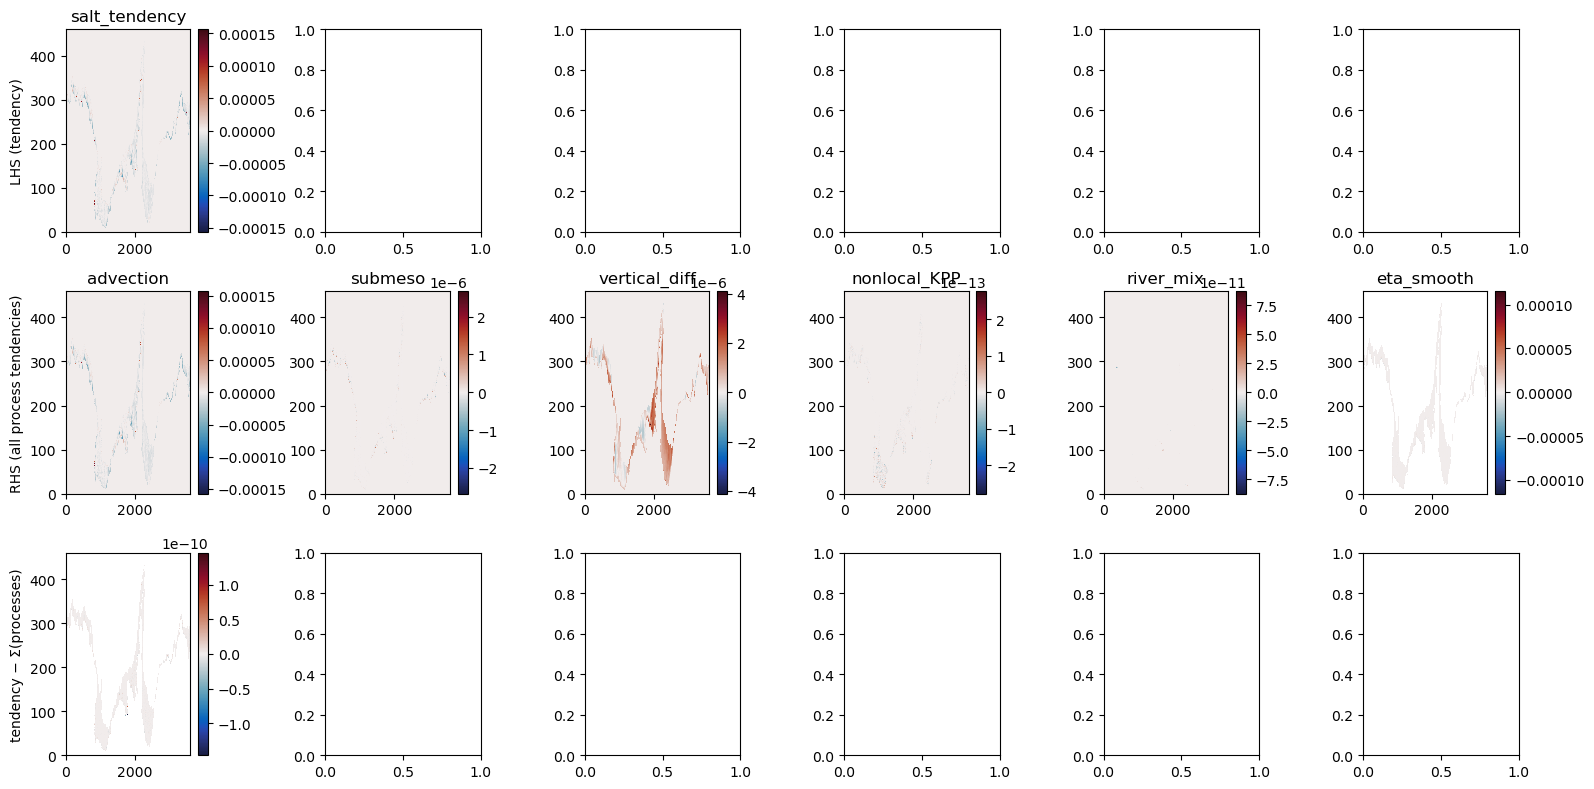

In [11]:
zdim = 'st_ocean'  # MOM6 vertical grid dimension

fig, ax = plt.subplots(
    figsize=(16, 8),
    nrows=3,
    ncols=max(len(lhs_salt), len(rhs_salt))
)
ax = ax.reshape(3, -1)  # flatten for consistent indexing

# -----------------------
# LHS terms
# -----------------------
for i, (name, da) in enumerate(lhs_salt.items()):

    da_masked = da.where(shelf_mask == 1)

    da2d = da_masked.sum(zdim).squeeze()

    if 'time' in da2d.dims:
        da2d = da2d.isel(time=0)

    da2d = da2d.compute()

    vmax = np.nanmax(np.abs(da2d))

    im = ax[0, i].pcolormesh(
        da2d, cmap=cm.cm.balance,
        vmax=vmax, vmin=-vmax
    )

    plt.colorbar(im, ax=ax[0, i])
    ax[0, i].set_title(name)

# -----------------------
# RHS terms
# -----------------------
for i, (name, da) in enumerate(rhs_salt.items()):

    da_masked = da.where(shelf_mask == 1)

    if zdim in da.dims:
        da2d = da_masked.sum(zdim)
    else:
        da2d = da_masked
    
    da2d = da2d.squeeze()

    if 'time' in da2d.dims:
        da2d = da2d.isel(time=0)

    da2d = da2d.compute()

    vmax = np.nanmax(np.abs(da2d))

    im = ax[1, i].pcolormesh(
        da2d, cmap=cm.cm.balance,
        vmax=vmax, vmin=-vmax
    )

    plt.colorbar(im, ax=ax[1, i])
    ax[1, i].set_title(name)


# -----------------------
# Closure residual
# -----------------------
lhs_total = data_2.salt_tendency

# Sum only 3D terms
lhs_col = lhs_total.sum(zdim)

rhs_col = (
    data_2.salt_advection.sum(zdim)
    + data_2.salt_submeso.sum(zdim)
    + data_2.salt_vdiffuse_impl.sum(zdim)
    + data_2.salt_nonlocal_KPP.sum(zdim)
    + data_2.salt_rivermix.sum(zdim)
)

# Now add the 2D correction ONCE
rhs_col = rhs_col + data_2.salt_eta_smooth

residual = lhs_col.where(shelf_mask == 1) - rhs_col.where(shelf_mask == 1)

if 'time' in residual.dims:
    residual = residual.isel(time=0)

residual = residual.compute()

vmax = np.abs(residual).max()

im = ax[2, 0].pcolormesh(
    residual, cmap=cm.cm.balance,
    vmin=-vmax, vmax=vmax
)

plt.colorbar(im, ax=ax[2, 0])

# -----------------------
# Row labels
# -----------------------
ax[0, 0].set_ylabel('LHS (tendency)')
ax[1, 0].set_ylabel('RHS (all process tendencies)')
ax[2, 0].set_ylabel('tendency − Σ(processes)')

plt.tight_layout()


#### Checking if we have closure:   
We are told that for the budget to be considered “closed” the difference between the LHS and RHS should be approximately 12 orders of magnitude smaller than the contributing terms.   
We also want to check whether there is off-shelf advection.  

In [12]:
# Note residual = (lhs_total - rhs_total).sum(zdim).squeeze()
residual

<xarray.DataArray (yt_ocean: 460, xt_ocean: 3600)> Size: 7MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * yt_ocean  (yt_ocean) float64 4kB -79.0 -78.95 -78.91 ... -59.08 -59.03
  * xt_ocean  (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95
    time      object 8B 1910-01-16 12:00:00
    geolon_t  (yt_ocean, xt_ocean) float32 7MB nan nan nan ... 79.75 79.85 79.95
    geolat_t  (yt_ocean, xt_ocean) float32 7MB nan nan nan ... -59.03 -59.03

In [13]:
residual.max().compute()

<xarray.DataArray ()> Size: 8B
array(7.54880602e-11)
Coordinates:
    time     object 8B 1910-01-16 12:00:00

In [14]:
residual.min().compute()

<xarray.DataArray ()> Size: 8B
array(-1.46428647e-10)
Coordinates:
    time     object 8B 1910-01-16 12:00:00

So budget is kind of closed? Only 3 orders of mag difference though, which isn't ideal.  
Can we approximate to **tendency = advection + surface forcing**? Check relative magnitude of LHS terms. 

In [16]:
# testing individual diagnostics
tendency = data_2.salt_tendency
advection = data_2.salt_advection
submeso = data_2.salt_submeso
vert_diff_surface = data_2.salt_vdiffuse_impl
nonlocal_KPP = data_2.salt_nonlocal_KPP
river_mix = data_2.salt_rivermix
eta_smooth = data_2.salt_eta_smooth

In [18]:
tendency_plot = tendency.isel(time=0).where(shelf_mask == 1).sum(zdim).squeeze()
advection_plot = advection.isel(time=0).where(shelf_mask == 1).sum(zdim).squeeze()
submeso_plot = submeso.isel(time=0).where(shelf_mask == 1).sum(zdim).squeeze()
vert_diff_surface_plot = vert_diff_surface.isel(time=0).where(shelf_mask == 1).sum(zdim).squeeze()
nonlocal_KPP_plot = nonlocal_KPP.isel(time=0).where(shelf_mask == 1).sum(zdim).squeeze()
river_mix_plot = river_mix.isel(time=0).where(shelf_mask == 1).sum(zdim).squeeze()
eta_smooth_plot = eta_smooth.isel(time=0).where(shelf_mask == 1)

In [19]:
tendency_plot = tendency_plot.compute()
advection_plot = advection_plot.compute()
submeso_plot = submeso_plot.compute()
vert_diff_surface_plot = vert_diff_surface_plot.compute()

In [20]:
nonlocal_KPP_plot = nonlocal_KPP_plot.compute()
river_mix_plot = river_mix_plot.compute()
eta_smooth_plot = eta_smooth_plot.compute()

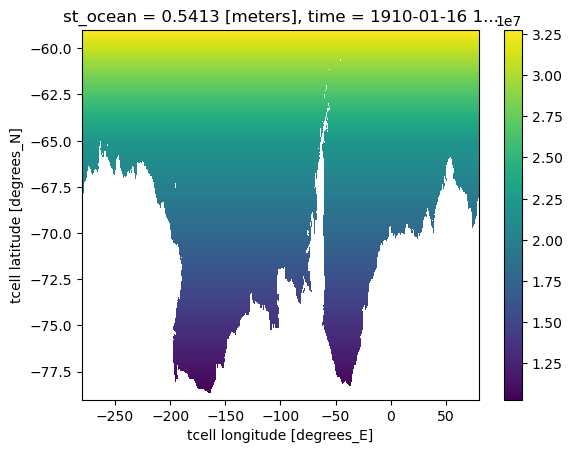

In [22]:
# Doing spatial average
area = xr.open_dataset('/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath/output012/ocean/ocean_grid.nc')['area_t']
var = data_2.salt.isel(time=0,st_ocean=0)
area_corr = area*(var*0 +1)
area_corr.plot()

In [23]:
tendency_ave = (area_corr * tendency_plot).sum(['xt_ocean', 'yt_ocean']) / area_corr.where(shelf_mask == 1).sum(['xt_ocean', 'yt_ocean'])
advection_ave = (area_corr * advection_plot).sum(['xt_ocean', 'yt_ocean']) / area_corr.where(shelf_mask == 1).sum(['xt_ocean', 'yt_ocean'])
submeso_ave = (area_corr * submeso_plot).sum(['xt_ocean', 'yt_ocean']) / area_corr.where(shelf_mask == 1).sum(['xt_ocean', 'yt_ocean'])
vert_diff_surface_ave = (area_corr * vert_diff_surface_plot).sum(['xt_ocean', 'yt_ocean']) / area_corr.where(shelf_mask == 1).sum(['xt_ocean', 'yt_ocean'])
nonlocal_KPP_ave = (area_corr * nonlocal_KPP_plot).sum(['xt_ocean', 'yt_ocean']) / area_corr.where(shelf_mask == 1).sum(['xt_ocean', 'yt_ocean'])
river_mix_ave = (area_corr * river_mix_plot).sum(['xt_ocean', 'yt_ocean']) / area_corr.where(shelf_mask == 1).sum(['xt_ocean', 'yt_ocean'])
eta_smooth_ave = (area_corr * eta_smooth_plot).sum(['xt_ocean', 'yt_ocean']) / area_corr.where(shelf_mask == 1).sum(['xt_ocean', 'yt_ocean'])

In [24]:
tendency_ave = tendency_ave.load()
advection_ave = advection_ave.load()
submeso_ave = submeso_ave.load()
vert_diff_surface_ave = vert_diff_surface_ave.load()
nonlocal_KPP_ave = nonlocal_KPP_ave.load()
river_mix_ave = river_mix_ave.load()
eta_smooth_ave = eta_smooth_ave.load()

**On average, how much salt per square metre is being added/removed from the shelf (full-depth integrated), due to...**

In [25]:
print("tendency =", tendency_ave.values, "\nadvection =", advection_ave.values, "\nsubmeso =", submeso_ave.values, "\nvertical diffusion and surface forcing =", 
      vert_diff_surface_ave.values, "\nnonlocal KPP =", nonlocal_KPP_ave.values, "\nriver mixing =", river_mix_ave.values, "\neta smoothing =", eta_smooth_ave.values)

tendency = -5.2008336e-06 
advection = -5.839086e-06 
submeso = -5.2396767e-11 
vertical diffusion and surface forcing = 6.498882e-07 
nonlocal KPP = 4.3169187e-18 
river mixing = 2.2943905e-15 
eta smoothing = -1.1583458e-08


So yes, tendency, horizontal advection, and surface forcing are the dominant terms.  
Also eta smoothing having some notable impact?  
We also see that the tendency is dominated by horizontal advection, far more than surface forcing.  
**BUT** this is just the control experiment. We need to look at the anomaly (pert - control) to see what's actually happening.

### Comparison with meltwater experiment

In [27]:
# Meltwater values
tendency_ave_M = -5.3658687e-06 
advection_ave_M = -5.7858183e-06 
submeso_ave_M = -6.483168e-11 
vert_diff_surface_ave_M = 4.3215172e-07 
nonlocal_KPP_ave_M = -1.7239344e-17 
river_mix_ave_M = -2.762257e-15 
eta_smooth_ave_M = -1.2137387e-08

# renaming control values
tendency_ave_C = tendency_ave.values
advection_ave_C = advection_ave.values
submeso_ave_C = submeso_ave.values
vert_diff_surface_ave_C = vert_diff_surface_ave.values
nonlocal_KPP_ave_C = nonlocal_KPP_ave.values
river_mix_ave_C = river_mix_ave.values
eta_smooth_ave_C = eta_smooth_ave.values

In [29]:
tendency_ave_anom = tendency_ave_M - tendency_ave_C
advection_ave_anom = advection_ave_M - advection_ave_C
submeso_ave_anom = submeso_ave_M - submeso_ave_C
vert_diff_surface_ave_anom = vert_diff_surface_ave_M - vert_diff_surface_ave_C
nonlocal_KPP_ave_anom = nonlocal_KPP_ave_M - nonlocal_KPP_ave_C
river_mix_ave_anom = river_mix_ave_M - river_mix_ave_C
eta_smooth_ave_anom = eta_smooth_ave_M - eta_smooth_ave_C

In [30]:
# Term labels
terms = [
    "Tendency",
    "Advection",
    "Submeso",
    "Vert diff and surface forcing",
    "Nonlocal KPP",
    "River mix",
    "Eta smooth"
]

# Anomaly values
anoms = [
    tendency_ave_anom,
    advection_ave_anom,
    submeso_ave_anom,
    vert_diff_surface_ave_anom,
    nonlocal_KPP_ave_anom,
    river_mix_ave_anom,
    eta_smooth_ave_anom
]

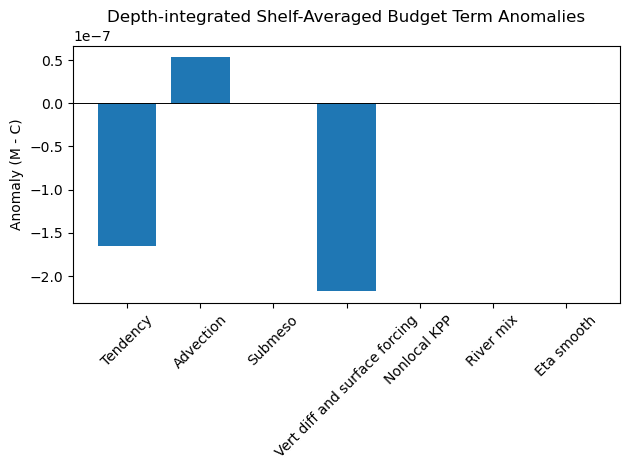

In [31]:
# Create figure
plt.figure()
plt.bar(terms, anoms)

plt.ylabel("Anomaly (M - C)")
#plt.ylim(-0.25e-5,2.5e-5)
plt.axhline(0, color='black', linewidth=0.7)
plt.title("Depth-integrated Shelf-Averaged Budget Term Anomalies")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Interpretation:
- Tendency indicates meltwater experiment freshens more on the shelf compared to control
- Freshening is due to surface forcing when we add meltwater.
- Reduced advection of salt off the shelf in meltwater vs control.

In [33]:
# M values
M_vals = [
    tendency_ave_M,
    advection_ave_M,
    submeso_ave_M,
    vert_diff_surface_ave_M,
    nonlocal_KPP_ave_M,
    river_mix_ave_M,
    eta_smooth_ave_M
]

# C values
C_vals = [
    tendency_ave_C,
    advection_ave_C,
    submeso_ave_C,
    vert_diff_surface_ave_C,
    nonlocal_KPP_ave_C,
    river_mix_ave_C,
    eta_smooth_ave_C
]

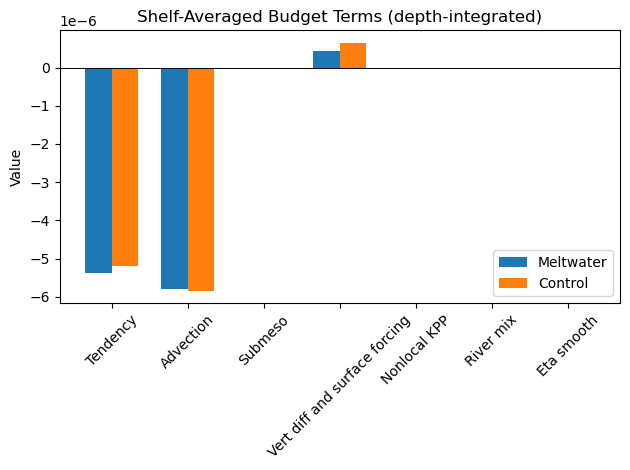

In [34]:
x = np.arange(len(terms))
width = 0.35

plt.figure()
plt.bar(x - width/2, M_vals, width, label="Meltwater")
plt.bar(x + width/2, C_vals, width, label="Control")

plt.xticks(x, terms, rotation=45)
plt.axhline(0, color='black', linewidth=0.7)
plt.ylabel("Value")
plt.title("Shelf-Averaged Budget Terms (depth-integrated)")
plt.legend()
plt.tight_layout()
plt.show()

Interpretation:
- Both control and meltwater experiments show overall freshening due to advection of salt off the shelf. 
- The difference between the experiments is driven by a slight reduction in the advection of the shelf, and a large decrease in the salt flux from surface forcing in the meltwater experiment. 

### Surface and bottom salinity for reference

In [37]:
import pandas as pd

In [38]:
data_1a_time = xr.open_dataarray('/g/data/g40/kc5856/access_panan_ssp126_SWMT/botsalt_anom_prescribed_access.nc', chunks = 'auto')
data_1b_time = xr.open_dataarray('/g/data/g40/kc5856/access_panan_ssp126_SWMT/topsalt_anom_prescribed_access.nc', chunks = 'auto')

In [40]:
data_1a_time_new = data_1a_time.to_series()
data_1b_time_new = data_1b_time.to_series()

data_1a_time_new = data_1a_time_new['1910-01-01':'1919-10-16']
data_1b_time_new = data_1b_time_new['1910-01-01':'1919-10-16']

data_1a_time_new.index = range(1, len(data_1a_time_new)+1)
data_1b_time_new.index = range(1, len(data_1b_time_new)+1)

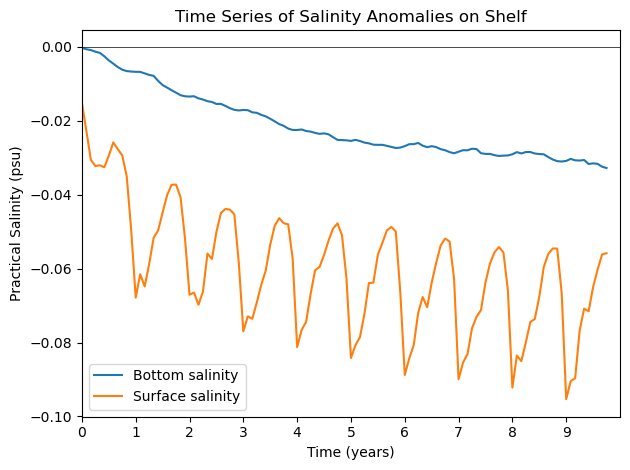

In [41]:
fig, ax = plt.subplots()

data_1a_time_new.plot(ax=ax, label="Bottom salinity")
data_1b_time_new.plot(ax=ax, label="Surface salinity")

ax.set_xticks(range(1, 121, 12))
ax.set_xticklabels([str(j) for j in range(0, 10)])

ax.axhline(0, color="black", linewidth=0.5)

ax.set_xlabel("Time (years)")
ax.set_xlim(1, 121)
# ax.set_ylim(-1.30, -0.70)

ax.set_ylabel("Practical Salinity (psu)")
ax.legend(loc="lower left")
ax.set_title("Time Series of Salinity Anomalies on Shelf")

plt.tight_layout()
plt.show()

In [42]:
data_1b_time_new

1     -0.015099
2     -0.022762
3     -0.030552
4     -0.032242
5     -0.032036
         ...   
114   -0.071533
115   -0.065018
116   -0.060299
117   -0.056171
118   -0.055828
Length: 118, dtype: float32

Note that at month one, we already have a surface salinity anomaly of -0.015 psu.